# Bayesian Optimization Meeting Overview

This notebook gives a short overview of the current Bayesian Optimization (BO) implementation and its comparison against Random Parameter Search. It is intended as a compact discussion artifact, not as a full technical report.

## 1. Goal

The goal is to optimize station and worker capacities for the lab simulation. The simulation is repeatedly evaluated with different capacity combinations. Ax/BO proposes new parameter combinations based on previous evaluations. Each configuration is evaluated with a weighted objective function that combines throughput, lateness, time in system, and capacity costs.

## 2. Decision Space

The optimizer chooses integer capacities for:

- `preparation_capacity`
- `sorting_capacity`
- `analysis1_capacity`
- `analysis2_capacity`
- `evaluation_capacity`
- `dispatching_capacity`
- `worker_capacity`

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
CWD = Path.cwd()
BO_ROOT = CWD.parent if CWD.name == "notebooks" else CWD / "BO" if (CWD / "BO").exists() else CWD
RESULTS_DIR = BO_ROOT / "results"

bo_trials = pd.read_csv(RESULTS_DIR / "bo_results" / "bo_trials.csv")
rs_trials = pd.read_csv(RESULTS_DIR / "random_search_results" / "random_search_trials.csv")

with open(RESULTS_DIR / "bo_results" / "bo_config.json", encoding="utf-8") as file:
    bo_config = json.load(file)

with open(RESULTS_DIR / "random_search_results" / "random_search_config.json", encoding="utf-8") as file:
    rs_config = json.load(file)

parameter_names = list(bo_config["PARAMETER_BOUNDS"].keys())

if "best_objective_so_far" not in bo_trials.columns:
    bo_trials["best_objective_so_far"] = bo_trials["objective_mean"].cummin()
if "best_objective_so_far" not in rs_trials.columns:
    rs_trials["best_objective_so_far"] = rs_trials["objective_mean"].cummin()

## 3. Experiment Setup

The BO and Random Search runs use the same simulation budget and the same objective function.

In [2]:
setup = pd.DataFrame(
    [
        {
            "method": "Bayesian Optimization",
            "N_TRIALS": bo_config["N_TRIALS"],
            "N_REPLICATIONS": bo_config["N_REPLICATIONS"],
            "RATE_MULTIPLIER": bo_config["RATE_MULTIPLIER"],
            "RUN_DURATION": bo_config["RUN_DURATION"],
        },
        {
            "method": "Random Search",
            "N_TRIALS": rs_config["N_TRIALS"],
            "N_REPLICATIONS": rs_config["N_REPLICATIONS"],
            "RATE_MULTIPLIER": rs_config["RATE_MULTIPLIER"],
            "RUN_DURATION": rs_config["RUN_DURATION"],
        },
    ]
)
setup

,method,N_TRIALS,N_REPLICATIONS,RATE_MULTIPLIER,RUN_DURATION
0,Bayesian Optimization,30,30,0.5,1440
1,Random Search,30,30,0.5,1440


### Objective Function

The current objective is minimized:

$$
J(x) = 1.0 \cdot \overline{T}_{system} - 10.0 \cdot N_{completed} + 50.0 \cdot N_{late} + 5.0 \cdot C_{worker} + 2.0 \cdot C_{stations}
$$

Where:

- $\overline{T}_{system}$: mean time in system
- $N_{completed}$: completed orders
- $N_{late}$: late orders
- $C_{worker}$: worker capacity
- $C_{stations}$: sum of all station capacities except worker capacity

Important: the current weights are experimental and directly influence the preferred capacity level.

In [3]:
weights = pd.Series(bo_config["OBJECTIVE_WEIGHTS"], name="weight").to_frame()
bounds = pd.DataFrame(bo_config["PARAMETER_BOUNDS"]).T.rename(columns={0: "lower", 1: "upper"})
display(weights)
display(bounds)

,weight
completed,1.00
late_total,3.00
station_capacity,0.80
worker_capacity,0.35
time_in_system_mean,0.40
time_in_system_std,0.20


,lower,upper
preparation_capacity,1,5
sorting_capacity,1,5
analysis1_capacity,1,5
analysis2_capacity,1,5
evaluation_capacity,1,5
dispatching_capacity,1,5
worker_capacity,1,10


## 4. Core Results

In [4]:
def best_summary(df, method):
    best = df.loc[df["objective_mean"].idxmin()].copy()
    return {
        "method": method,
        "objective": best["objective_mean"],
        "orders_completed": best["n_orders_completed_mean"],
        "late_orders": best["n_orders_late_mean"],
        "late_order_fraction": best["late_order_fraction_mean"],
        "time_in_system_mean": best["time_in_system_mean_mean"],
        "wip_mean": best["wip_mean_mean"],
        "total_capacity": best[parameter_names].sum(),
    }

result_summary = pd.DataFrame(
    [best_summary(bo_trials, "Bayesian Optimization"), best_summary(rs_trials, "Random Search")]
)
result_summary.round(3)

,method,objective,orders_completed,late_orders,late_order_fraction,time_in_system_mean,wip_mean,total_capacity
0,Bayesian Optimization,-0.131,974.833,0.0,0.0,23.533,16.237,29
1,Random Search,0.190,934.367,0.0,0.0,43.623,32.626,33


In [5]:
best_params = pd.DataFrame(
    [
        bo_trials.loc[bo_trials["objective_mean"].idxmin(), parameter_names].rename("Bayesian Optimization"),
        rs_trials.loc[rs_trials["objective_mean"].idxmin(), parameter_names].rename("Random Search"),
    ]
)
best_params["total_capacity"] = best_params.sum(axis=1)
best_params

,preparation_capacity,sorting_capacity,analysis1_capacity,analysis2_capacity,evaluation_capacity,dispatching_capacity,worker_capacity,total_capacity
Bayesian Optimization,4,4,5,4,4,1,7,29
Random Search,5,4,4,1,5,5,9,33


## 5. Visualizations

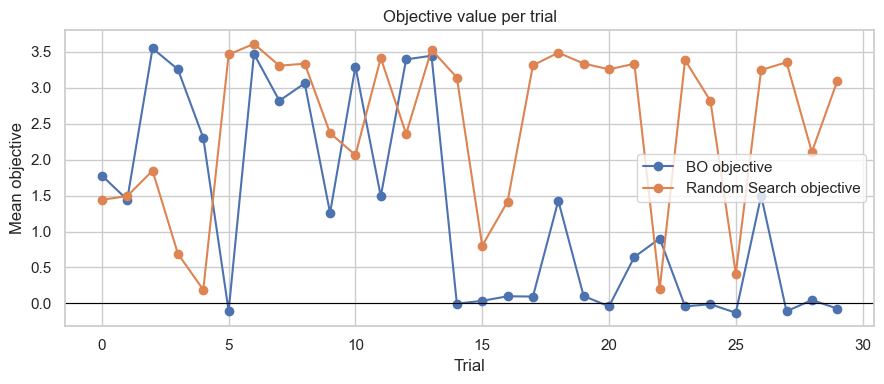

In [6]:
plt.figure(figsize=(9, 4))
plt.plot(bo_trials["trial_index"], bo_trials["objective_mean"], marker="o", label="BO objective")
plt.plot(rs_trials["trial_index"], rs_trials["objective_mean"], marker="o", label="Random Search objective")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Objective value per trial")
plt.xlabel("Trial")
plt.ylabel("Mean objective")
plt.legend()
plt.tight_layout()

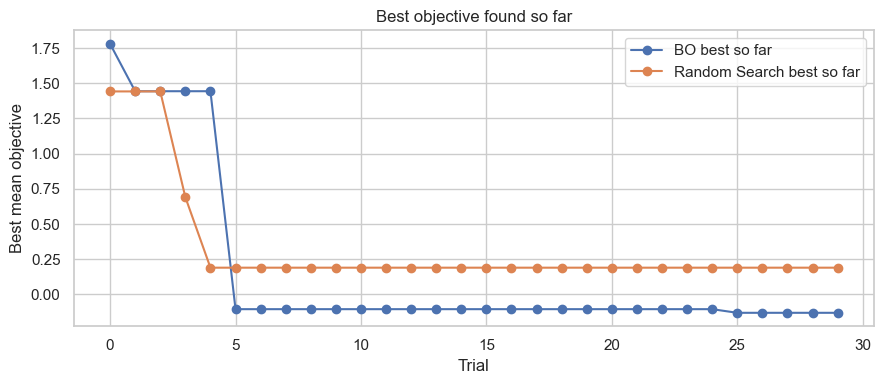

In [7]:
plt.figure(figsize=(9, 4))
plt.plot(bo_trials["trial_index"], bo_trials["best_objective_so_far"], marker="o", label="BO best so far")
plt.plot(rs_trials["trial_index"], rs_trials["best_objective_so_far"], marker="o", label="Random Search best so far")
plt.title("Best objective found so far")
plt.xlabel("Trial")
plt.ylabel("Best mean objective")
plt.legend()
plt.tight_layout()

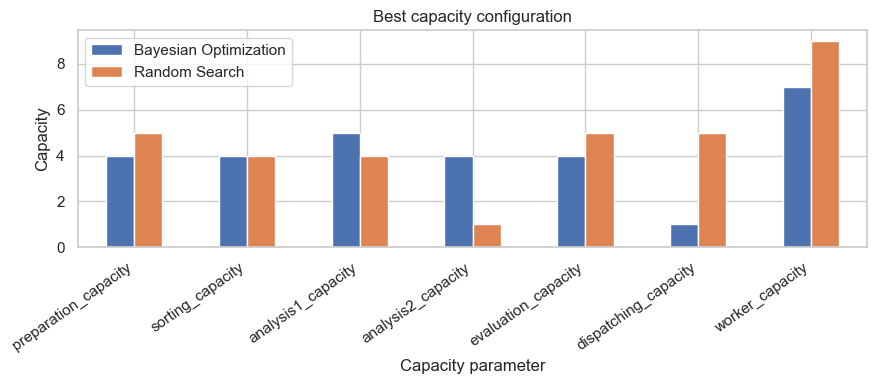

In [8]:
capacity_plot = best_params[parameter_names].T
capacity_plot.plot(kind="bar", figsize=(9, 4))
plt.title("Best capacity configuration")
plt.xlabel("Capacity parameter")
plt.ylabel("Capacity")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

## 6. Interpretation

- BO currently finds the best objective value in the available experiment results.
- Both BO and Random Search find configurations with zero late orders in their best trial.
- The BO best solution achieves higher throughput and lower mean time in system than the Random Search best solution in the current run.
- The objective strongly rewards completed orders and only mildly penalizes capacity, so high-capacity solutions are attractive.
- The objective weights are therefore a central modelling decision, not only a technical tuning detail.
- The comparison is now fair in simulation budget, but additional random-search seeds could be used if more robustness is required.

## 7. Discussion Points

- Should the final optimization use a weighted objective or explicit constraints, for example zero late orders first and minimal capacity second?
- Design Space Simulation:Is standard late fraction of 50% a fair comparison point between Optimizations?
- Which capacity costs are realistic enough for the written thesis?
- Is BO vs Random Search sufficient as the main algorithmic comparison?
- Which KPIs should be prioritized in the final text: throughput, lateness, time in system, WIP, or capacity cost?

## Discussion/TODO
- Multiple Runs (~20) with each 30 trials for Comparison BO and Random search results.
- Norming of terms.
- Higher weights for capacities (workers<stations)
- Counting late orders in system during run end and time in system of wip orders still in system at run end.
- Adding time in system std and mean to objective (high scaling)